In [1]:
import jieba
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
a1=pd.read_csv("train.csv")
a1.head()

,id,level_1,level_2,level_3,level_4,content,label
0,0,工业/危化品类（现场）—2016版,（二）电气安全,6、移动用电产品、电动工具及照明,1、移动使用的用电产品和I类电动工具的绝缘线，必须采用三芯(单相)或四芯(三相)多股铜芯橡套软线。,"使用移动手动电动工具,外接线绝缘皮破损,应停止使用.",0
1,1,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,3、消防设施、器材和消防安全标志是否在位、完整；,一般,1
2,2,工业/危化品类（现场）—2016版,（一）消防检查,2、防火检查,6、重点工种人员以及其他员工消防知识的掌握情况；,消防知识要加强,0
3,3,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,3、消防设施、器材和消防安全标志是否在位、完整；,消防通道有货物摆放 清理不及时,0
4,4,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,4、常闭式防火门是否处于关闭状态，防火卷帘下是否堆放物品影响使用；,防火门打开状态,0


In [3]:
a1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       12000 non-null  int64 
 1   level_1  12000 non-null  object
 2   level_2  12000 non-null  object
 3   level_3  12000 non-null  object
 4   level_4  12000 non-null  object
 5   content  11998 non-null  object
 6   label    12000 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 656.4+ KB


In [4]:
a1[['level_1','level_2','level_3','level_4','content']]=a1[['level_1','level_2','level_3','level_4','content']].fillna('')

In [5]:
a1['text']=a1["level_1"]+"="+a1['level_2']+"="+a1['level_3']+"="+a1['level_4']+"="+a1['content']
a1['text'].head()

0    工业/危化品类（现场）—2016版=（二）电气安全=6、移动用电产品、电动工具及照明=1、移...
1    工业/危化品类（现场）—2016版=（一）消防检查=1、防火巡查=3、消防设施、器材和消防安...
2    工业/危化品类（现场）—2016版=（一）消防检查=2、防火检查=6、重点工种人员以及其他员...
3    工业/危化品类（现场）—2016版=（一）消防检查=1、防火巡查=3、消防设施、器材和消防安...
4    工业/危化品类（现场）—2016版=（一）消防检查=1、防火巡查=4、常闭式防火门是否处于关...
Name: text, dtype: object

In [6]:
a1['len']=a1['text'].map(len)
# a1['len']=a1['text'].apply(len)
a1.len.head()

0    119
1     60
2     65
3     73
4     74
Name: len, dtype: int64

In [7]:
import re
import jieba

In [8]:
def task(text):
    text=re.sub('[^\u4e00-\u9fa5]+',"",text)
    return text

In [9]:
a4=task(a1['text'][0])
a4

'工业危化品类现场版二电气安全移动用电产品电动工具及照明移动使用的用电产品和类电动工具的绝缘线必须采用三芯单相或四芯三相多股铜芯橡套软线使用移动手动电动工具外接线绝缘皮破损应停止使用'

In [10]:
a1.head()

,id,level_1,level_2,level_3,level_4,content,label,text,len
0,0,工业/危化品类（现场）—2016版,（二）电气安全,6、移动用电产品、电动工具及照明,1、移动使用的用电产品和I类电动工具的绝缘线，必须采用三芯(单相)或四芯(三相)多股铜芯橡套软线。,"使用移动手动电动工具,外接线绝缘皮破损,应停止使用.",0,工业/危化品类（现场）—2016版=（二）电气安全=6、移动用电产品、电动工具及照明=1、移...,119
1,1,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,3、消防设施、器材和消防安全标志是否在位、完整；,一般,1,工业/危化品类（现场）—2016版=（一）消防检查=1、防火巡查=3、消防设施、器材和消防安...,60
2,2,工业/危化品类（现场）—2016版,（一）消防检查,2、防火检查,6、重点工种人员以及其他员工消防知识的掌握情况；,消防知识要加强,0,工业/危化品类（现场）—2016版=（一）消防检查=2、防火检查=6、重点工种人员以及其他员...,65
3,3,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,3、消防设施、器材和消防安全标志是否在位、完整；,消防通道有货物摆放 清理不及时,0,工业/危化品类（现场）—2016版=（一）消防检查=1、防火巡查=3、消防设施、器材和消防安...,73
4,4,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,4、常闭式防火门是否处于关闭状态，防火卷帘下是否堆放物品影响使用；,防火门打开状态,0,工业/危化品类（现场）—2016版=（一）消防检查=1、防火巡查=4、常闭式防火门是否处于关...,74


In [11]:
a1['jieba_cut_text']=a1['text'].apply(lambda x:','.join([w for w in jieba.cut(x)]))
a1.head()

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\HUAWEI\AppData\Local\Temp\jieba.cache
Loading model cost 1.122 seconds.
Prefix dict has been built successfully.


,id,level_1,level_2,level_3,level_4,content,label,text,len,jieba_cut_text
0,0,工业/危化品类（现场）—2016版,（二）电气安全,6、移动用电产品、电动工具及照明,1、移动使用的用电产品和I类电动工具的绝缘线，必须采用三芯(单相)或四芯(三相)多股铜芯橡套软线。,"使用移动手动电动工具,外接线绝缘皮破损,应停止使用.",0,工业/危化品类（现场）—2016版=（二）电气安全=6、移动用电产品、电动工具及照明=1、移...,119,"工业,/,危化,品类,（,现场,）,—,2016,版,=,（,二,）,电气,安全,=,6,、..."
1,1,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,3、消防设施、器材和消防安全标志是否在位、完整；,一般,1,工业/危化品类（现场）—2016版=（一）消防检查=1、防火巡查=3、消防设施、器材和消防安...,60,"工业,/,危化,品类,（,现场,）,—,2016,版,=,（,一,）,消防,检查,=,1,、..."
2,2,工业/危化品类（现场）—2016版,（一）消防检查,2、防火检查,6、重点工种人员以及其他员工消防知识的掌握情况；,消防知识要加强,0,工业/危化品类（现场）—2016版=（一）消防检查=2、防火检查=6、重点工种人员以及其他员...,65,"工业,/,危化,品类,（,现场,）,—,2016,版,=,（,一,）,消防,检查,=,2,、..."
3,3,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,3、消防设施、器材和消防安全标志是否在位、完整；,消防通道有货物摆放 清理不及时,0,工业/危化品类（现场）—2016版=（一）消防检查=1、防火巡查=3、消防设施、器材和消防安...,73,"工业,/,危化,品类,（,现场,）,—,2016,版,=,（,一,）,消防,检查,=,1,、..."
4,4,工业/危化品类（现场）—2016版,（一）消防检查,1、防火巡查,4、常闭式防火门是否处于关闭状态，防火卷帘下是否堆放物品影响使用；,防火门打开状态,0,工业/危化品类（现场）—2016版=（一）消防检查=1、防火巡查=4、常闭式防火门是否处于关...,74,"工业,/,危化,品类,（,现场,）,—,2016,版,=,（,一,）,消防,检查,=,1,、..."


In [12]:
total_words=','.join(a1['jieba_cut_text'].apply(lambda x:x))

In [13]:
from wordcloud import WordCloud

In [14]:
import matplotlib.pyplot as plt

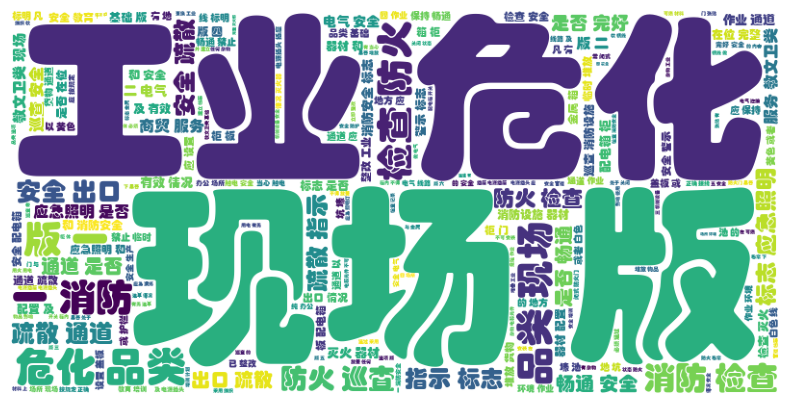

In [15]:
wordcould=WordCloud(
    font_path='./STHUPO.TTF',
    width=800,
    height=400,
    background_color='white'
).generate(total_words)
plt.figure(figsize=(10,5))
plt.imshow(wordcould)
plt.axis('off')
plt.show()

In [16]:
import stylecloud
stylecloud.gen_stylecloud(
    font_path='./STHUPO.TTF',
    icon_name='fas fa-heart',
    text=total_words,
    size=500,
    output_name="./Cloud_img/heart_cloud.png"
)

In [17]:
stylecloud.gen_stylecloud(
    text=total_words,
    font_path='./STXINGKA.TTF',
    size=400,
    icon_name='fas fa-plane',
    background_color='white',
    
    output_name='./Cloud_img/plane_cloud.png'
)

In [18]:
stylecloud.gen_stylecloud(
    text=total_words,
    font_path='./STXINGKA.TTF',
    size=400,
    icon_name='fas fa-user',
    background_color='white',
    output_name='./Cloud_img/user_cloud.png'
)

In [19]:
stylecloud.gen_stylecloud(
    text=total_words,
    font_path='./STXINGKA.TTF',
    size=400,
    icon_name='fas fa-thumbs-up',
    background_color='white',
    output_name='./Cloud_img/thumb_up_cloud.png'
)

In [20]:
stylecloud.gen_stylecloud(
    text=total_words,
    font_path='./STXINGKA.TTF',
    size=400,
    icon_name='fas fa-search',
    background_color='white',
    output_name='./Cloud_img/search_cloud.png'
)